In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Monte Carlo simulation of the Brownian bridge
# dX = (b-X)/(T-t)*dt + sigma*dW

In [2]:
# Parameters and time grid
npaths = 20000  # Number of paths
T = 1           # Time horizon
nsteps = 200    # Number of time steps
dt = T / nsteps  # Time step
t = np.linspace(0, T, nsteps + 1)  # Observation times
sigma = 0.3     # Volatility
a = 0.8         # Initial value
b = 1           # Final value

In [3]:
# Monte Carlo method 1: Euler-Maruyama method for Brownian bridge

# Allocate and initialize all paths
X = np.zeros((nsteps + 1, npaths))
X[0, :] = a  # Initial value
X[-1, :] = b  # Final value

# Compute the Brownian bridge with Euler-Maruyama method
for i in range(1, nsteps):
    X[i, :] = X[i - 1, :] + (b - X[i - 1, :]) / (nsteps - i + 1) + sigma * np.random.randn(npaths) * np.sqrt(dt)


Text(0.5, 1.0, 'Brownian bridge $dX = \\frac{(b-X)}{(T-t)} dt + \\sigma dW$')

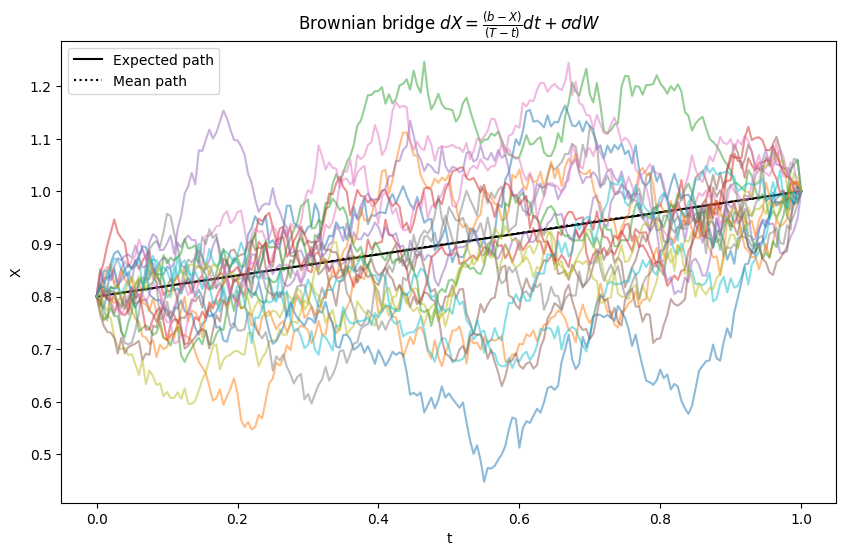

In [4]:
plt.figure(figsize=(10, 6))
EX = a + (b - a) / T * t  # Expected path
plt.plot(t, EX, 'k', label='Expected path')
plt.plot(t, np.mean(X, axis=1), ':k', label='Mean path')
plt.plot(t, X[:, ::1000], alpha=0.5)  # Plot a subset of paths for clarity
plt.legend()
plt.xlabel('t')
plt.ylabel('X')
plt.title('Brownian bridge $dX = \\frac{(b-X)}{(T-t)} dt + \\sigma dW$')